# ResNet50 binary classifier — corrected, leakage-free split

This notebook retrains the identical architecture/hyperparameters used in
`train_resnet50.ipynb`, but on a **group-level (lesion-level) split** built by
`make_group_split.py`.

**Why this notebook exists:** `train_resnet50.ipynb` splits the *Augmented
Dataset* 80/20 into train/validation, then evaluates on the *Original Dataset*
as a supposedly "unseen" test set. `audit_leakage.py` proves that's not a
valid holdout: the Augmented Dataset's own generator script re-saves an
unmodified copy of every original into the augmented folder under the same
filename, so 100% of the "unseen" test lesions have at least one variant
(often the byte-for-byte-same-content original) sitting inside the training
split. See the root `README.md` and this folder's `README.md` for the full
finding.

This notebook fixes that by splitting **lesions**, not files: every original
image and its 12 augmented variants are kept together in exactly one of
train/val/test, so no test lesion's pixels are ever seen during training.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import models, transforms
import os
import csv
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


PyTorch version: 2.5.1+cu121
CUDA available: True
Using device: cuda:0
GPU: NVIDIA GeForce RTX 3060 Ti


## Load the group-level split

Built by `make_group_split.py` from the *Augmented Dataset* only — the Original Dataset is never touched during training, so it stays available as an independent sanity check if desired, but the real held-out set here is `splits/test.csv`.

In [2]:
SPLITS_DIR = "splits"
REPO_ROOT = ".."  # this notebook lives in 1_binary_classification_mendeley/
CLASS_NAMES = ["Cancer", "Non-Cancer"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}


def load_split(name):
    rows = []
    with open(os.path.join(SPLITS_DIR, f"{name}.csv"), newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            rows.append((row["path"], row["label"]))
    return rows


train_rows = load_split("train")
val_rows = load_split("val")
test_rows = load_split("test")

print(f"train: {len(train_rows)} files")
print(f"val:   {len(val_rows)} files")
print(f"test:  {len(test_rows)} files")


train: 7761 files
val:   962 files
test:  962 files


In [3]:
class CsvImageDataset(torch.utils.data.Dataset):
    """Loads images from a (path, label) list instead of an ImageFolder tree,
    so we don't need to physically copy the LFS-tracked dataset into new
    train/val/test directories."""

    def __init__(self, rows, transform):
        self.rows = rows
        self.transform = transform

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        rel_path, label = self.rows[idx]
        img_path = os.path.join(REPO_ROOT, rel_path)
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)
        return image, CLASS_TO_IDX[label]


In [4]:
# Same transforms as train_resnet50.ipynb
data_transforms = {
    "train": transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
    "eval": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
}

image_datasets = {
    "train": CsvImageDataset(train_rows, data_transforms["train"]),
    "validation": CsvImageDataset(val_rows, data_transforms["eval"]),
    "test": CsvImageDataset(test_rows, data_transforms["eval"]),
}

dataloaders = {
    "train": torch.utils.data.DataLoader(image_datasets["train"], batch_size=32, shuffle=True, num_workers=0),
    "validation": torch.utils.data.DataLoader(image_datasets["validation"], batch_size=32, shuffle=False, num_workers=0),
    "test": torch.utils.data.DataLoader(image_datasets["test"], batch_size=32, shuffle=False, num_workers=0),
}

dataset_sizes = {x: len(image_datasets[x]) for x in ["train", "validation", "test"]}
print(dataset_sizes)
class_names = CLASS_NAMES


{'train': 7761, 'validation': 962, 'test': 962}


## Model — identical architecture and hyperparameters as `train_resnet50.ipynb`

ResNet50 pretrained on ImageNet, final layer replaced for 2 classes, AdamW lr=1e-3, StepLR(step_size=7, gamma=0.1), CrossEntropyLoss, 15 epochs.

In [5]:
model_ft = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, len(class_names))
model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.AdamW(model_ft.parameters(), lr=0.001)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

print("ResNet50 loaded and final layer modified.")


ResNet50 loaded and final layer modified.


In [6]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=15):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    print("\nStarting training...")
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}/{num_epochs - 1}")
        print("-" * 10)

        for phase in ["train", "validation"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == "train":
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            history_key = "train" if phase == "train" else "val"
            history[f"{history_key}_loss"].append(epoch_loss)
            history[f"{history_key}_acc"].append(epoch_acc.item())

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == "validation" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best validation Acc: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history


In [7]:
num_epochs_to_train = 15  # identical to train_resnet50.ipynb

model_ft, history = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                                 num_epochs=num_epochs_to_train)



Starting training...
Epoch 0/14
----------


train Loss: 0.3125 Acc: 0.8901


validation Loss: 0.2377 Acc: 0.9231

Epoch 1/14
----------


train Loss: 0.2567 Acc: 0.9040


validation Loss: 0.2022 Acc: 0.9158

Epoch 2/14
----------


...

validation Loss: 0.0838 Acc: 0.9678

Epoch 13/14
----------


train Loss: 0.1242 Acc: 0.9485


validation Loss: 0.1814 Acc: 0.9428

Epoch 14/14
----------


train Loss: 0.1233 Acc: 0.9505


validation Loss: 0.0657 Acc: 0.9751

Training complete in 35m 10s
Best validation Acc: 0.9751


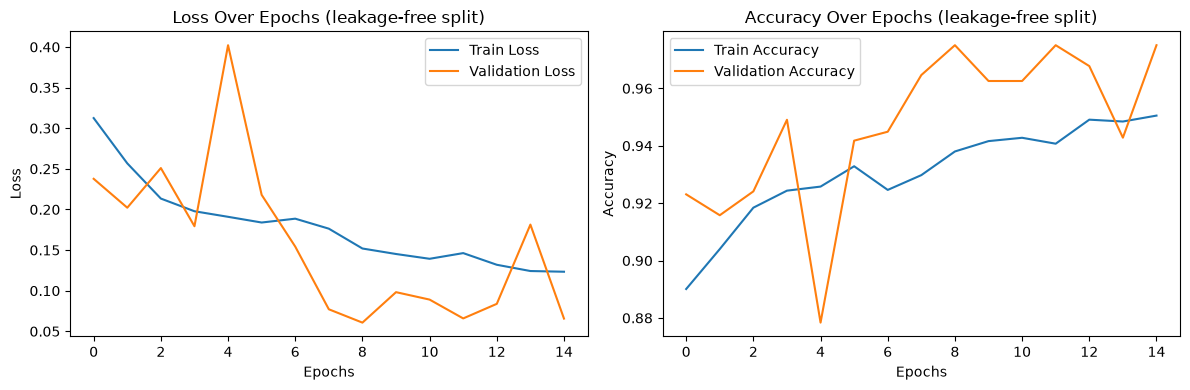

In [8]:
def plot_history(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title("Loss Over Epochs (leakage-free split)")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"], label="Validation Accuracy")
    plt.title("Accuracy Over Epochs (leakage-free split)")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig("resnet50_model/groupsplit_training_curves.png", dpi=120)
    plt.show()


plot_history(history)


In [9]:
save_path = "resnet50_model/resnet50_groupsplit_weights.pth"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
torch.save(model_ft.state_dict(), save_path)
print(f"Best model weights saved to {save_path}")


Best model weights saved to resnet50_model/resnet50_groupsplit_weights.pth


## Evaluate on the genuinely held-out test set

`splits/test.csv` — lesions never seen in any form during training or validation. Report accuracy against the majority-class baseline, plus confusion matrix, per-class precision/recall, and ROC-AUC, since accuracy alone is close to uninformative on a ~74-lesion test set with class imbalance.

In [10]:
model_ft.eval()
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for inputs, labels in dataloaders["test"]:
        inputs = inputs.to(device)
        outputs = model_ft(inputs)
        probs = torch.softmax(outputs, dim=1)[:, CLASS_TO_IDX["Cancer"]]
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

test_acc = (all_labels == all_preds).mean()
majority_baseline = max(np.bincount(all_labels)) / len(all_labels)

print(f"Test accuracy (leakage-free, {len(all_labels)} images): {test_acc:.4f}")
print(f"Majority-class baseline on this test set: {majority_baseline:.4f}")
print()
print("Confusion matrix (rows=true, cols=pred), order:", class_names)
print(confusion_matrix(all_labels, all_preds))
print()
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

cancer_idx = CLASS_TO_IDX["Cancer"]
auc = roc_auc_score((all_labels == cancer_idx).astype(int), all_probs)
print(f"ROC-AUC (Cancer positive class): {auc:.4f}")


Test accuracy (leakage-free, 962 images): 0.9709
Majority-class baseline on this test set: 0.8378

Confusion matrix (rows=true, cols=pred), order: ['Cancer', 'Non-Cancer']
[[142  14]
 [ 14 792]]

              precision    recall  f1-score   support

      Cancer     0.9103    0.9103    0.9103       156
  Non-Cancer     0.9826    0.9826    0.9826       806

    accuracy                         0.9709       962
   macro avg     0.9464    0.9464    0.9464       962
weighted avg     0.9709    0.9709    0.9709       962

ROC-AUC (Cancer positive class): 0.9931


## Result

Fill in after running: honest test accuracy, majority baseline, confusion matrix and AUC from the cell above, for the CV write-up and READMEs. This is the number that replaces the 99.7% figure — report it even if (especially if) it is much lower.